In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import h5py
import nibabel as nib
import os

import torch
from juart import (
    cgnufft,
    cgsense,
)

In [2]:
h5_path = '/home/jovyan/scripts/juart/examples/dl/ga_kooshball/preprocessing/meas_MID00149_FID31870_Kooshball_GRE_30000_preproc-2.h5'
build_path = './build/meas_MID00149_FID31870_Kooshball_GRE_30000_reco/'

device = 'cuda:1'

In [3]:
# Load h5 file with preprocessed data
h5_dat = h5py.File(h5_path, 'r')
print("Datasets in HDF5 file:", list(h5_dat.keys()))

if not os.path.exists(build_path):
    os.makedirs(build_path)

h5_output = h5py.File(build_path + 'conventional_reco.h5', 'w')

Datasets in HDF5 file: ['cc_matrix', 'data_comp', 'data_comp_midres', 'sens_maps', 'traj', 'traj_midres', 'us_10', 'us_4', 'us_6', 'us_8']


In [4]:
# Access datasets
data = h5_dat['data_comp_midres'][:]
traj = h5_dat['traj_midres'][:]
coil_sens = h5_dat['sens_maps'][:]


print("Data shape:", data.shape)
print("Trajectory shape:", traj.shape)
print("Coil sensitivity maps shape:", coil_sens.shape)

matrix = coil_sens.shape[:3]

Data shape: (1, 128, 29900, 8)
Trajectory shape: (3, 128, 29900)
Coil sensitivity maps shape: (128, 128, 128, 8)


In [5]:
# Reshape to JUART data format

data = data[0].reshape(-1, data.shape[-1]).transpose(1, 0)
traj = traj.reshape(3, -1)

data = torch.from_numpy(data)
traj = torch.from_numpy(traj)

traj = traj/(torch.max(torch.abs(traj)) * 2)

coil_sens = np.moveaxis(coil_sens, -1, 0)  # coils first
coil_sens = torch.from_numpy(coil_sens)

In [6]:
img_tmp = cgnufft(
    ksp=data.to(device),
    ktraj=traj.to(device),
    img_size=(128, 128, 128),
    maxiter=100,
    l2_reg=1e-9,
    verbose=3
)

[CG] Iter: 100 Res: 4.14E-02 : 100%|██████████| 100/100 [00:03<00:00, 25.55it/s]


In [7]:
img_tmp_adaptcomb = torch.sum(img_tmp * torch.conj(coil_sens).to(device), dim=0)

In [8]:
h5_output.create_dataset('fs_nufft_coilcomb', data=img_tmp_adaptcomb.to('cpu'))
h5_output.create_dataset('fs_nufft', data=img_tmp.to('cpu'))



<HDF5 dataset "fs_nufft": shape (8, 128, 128, 128), type "<c8">

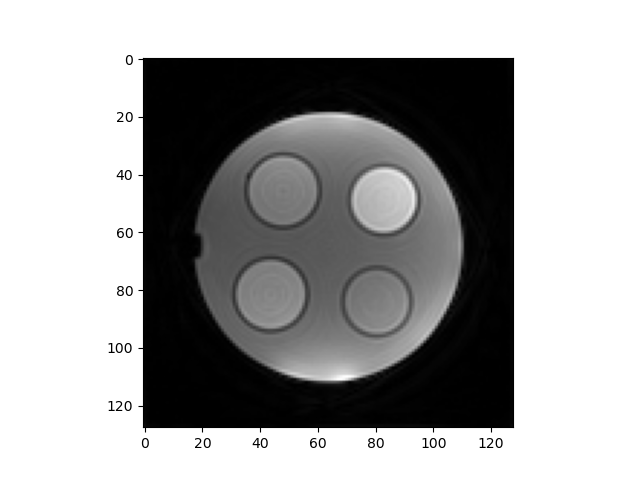

In [9]:
plt.figure()
plt.imshow(torch.abs(img_tmp_adaptcomb[:, :, 128//2]).cpu().numpy(), cmap='gray')

# Load undersampled data

In [10]:
# Reshape to JUART data format

data_us = h5_dat['us_10/data'][:]
traj_us = h5_dat['us_10/traj'][:]

print("Undersampled Data shape:", data_us.shape)
print("Undersampled Trajectory shape:", traj_us.shape)

data_us = data_us[0].reshape(-1, data_us.shape[-1]).transpose(1, 0)
traj_us = traj_us.reshape(3, -1)

data_us = torch.from_numpy(data_us)
traj_us = torch.from_numpy(traj_us)

traj_us = traj_us/(torch.max(torch.abs(traj_us)) * 2)

print("Undersampled data shape after reshape:", data_us.shape)
print("Undersampled trajectory shape after reshape:", traj_us.shape)


Undersampled Data shape: (1, 128, 2990, 8)
Undersampled Trajectory shape: (3, 128, 2990)
Undersampled data shape after reshape: torch.Size([8, 382720])
Undersampled trajectory shape after reshape: torch.Size([3, 382720])


In [11]:
img_us_nufft = cgnufft(
    ksp=data_us.to(device),
    ktraj=traj_us.to(device),
    img_size=(128, 128, 128),
    maxiter=150,
    l2_reg=1e-9,
    verbose=3
)

img_us_adaptcomb = torch.sum(img_us_nufft * torch.conj(coil_sens).to(device), dim=0)

[CG] Iter: 150 Res: 1.15E-03 : 100%|██████████| 150/150 [00:05<00:00, 25.41it/s]


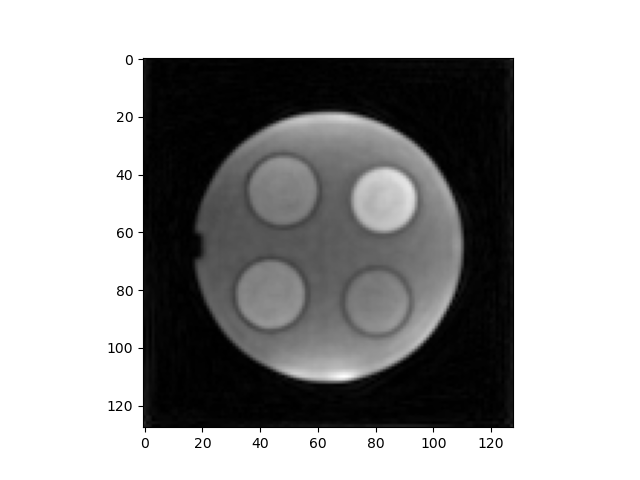

In [12]:
plt.figure()
plt.imshow(torch.abs(img_us_adaptcomb[:, :, 128//2]).cpu().numpy(), cmap='gray')

In [13]:
if 'us10_nufft_coilcomb' in h5_output:
    del h5_output['us10_nufft_coilcomb']
h5_output.create_dataset('us10_nufft_coilcomb', data=img_us_adaptcomb.to('cpu'))
if 'us10_nufft' in h5_output:
    del h5_output['us10_nufft']
h5_output.create_dataset('us10_nufft', data=img_us_nufft.to('cpu'))

<HDF5 dataset "us10_nufft": shape (8, 128, 128, 128), type "<c8">

In [14]:
img_sense = cgsense(
    ksp=data_us[..., None].to(device),
    ktraj=traj_us[..., None].to(device),
    coilsens=coil_sens[..., None].to(device),
    maxiter=100,
    l2_reg=1e-6,
    verbose=5
)

[CG] Iter: 100 Res: 4.06E-03 : 100%|██████████| 100/100 [00:03<00:00, 25.29it/s]


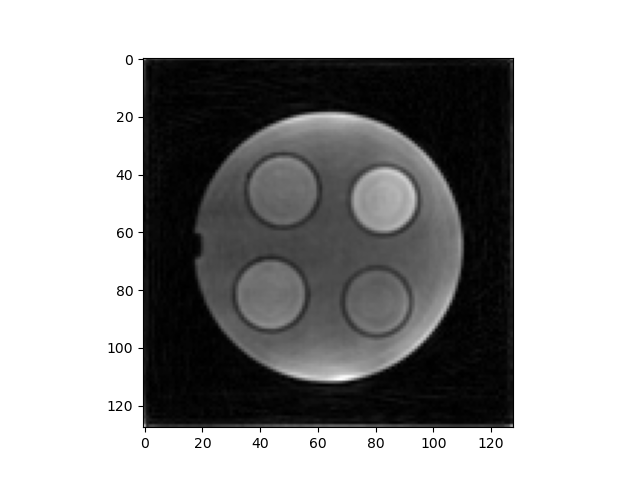

In [15]:
plt.figure()
plt.imshow(torch.abs(img_sense[0, :, :, 128//2]).cpu().numpy(), cmap='gray')

In [16]:
if 'us10_sense_mag' in h5_output:
    del h5_output['us10_sense_mag']
h5_output.create_dataset('us10_sense_mag', data=torch.abs(img_sense).to('cpu'))
if 'us10_sense_mag' in h5_output:
    del h5_output['us10_sense_mag']
h5_output.create_dataset('us10_sense_mag', data=torch.angle(img_sense).to('cpu'))


<HDF5 dataset "us10_sense_mag": shape (1, 128, 128, 128, 1), type "<f4">

# Compressed sensing reconstruction

In [17]:
from juart.recon.regsense import REGSENSE
from juart.conopt.functional.fourier import (
    nonuniform_fourier_transform_adjoint,
)

from juart.conopt.tfs.fourier import (
    nonuniform_transfer_function,
)


In [18]:
# Collaps additional dimensions
ksp = data_us.to(device)
ktraj = traj_us.to(device)
coil_sens_cs = coil_sens.to(device)

print("K-space data shape", ksp.shape)
print("K-space trajectory shape", ktraj.shape)
print("Coil sensitivities shape", coil_sens_cs.shape)

regridded_data = nonuniform_fourier_transform_adjoint(
    k=ktraj,
    x=ksp,
    n_modes=(128, 128, 128),
)

transfer_function = nonuniform_transfer_function(
    k=ktraj,
    data_shape=(1, *regridded_data.shape[1:]),
)

regridded_data = torch.sum(
    torch.conj(coil_sens_cs) * regridded_data, dim=0, keepdim=True
)

# Add slab, TI and TE dimension
coil_sens_cs = coil_sens_cs[..., None]
regridded_data = regridded_data[..., None, None, None]
transfer_function = transfer_function[..., None, None, None]

print("Shape of transfer function:", transfer_function.shape)
print("Shape of regridded data after coil combination:", regridded_data.shape)
print("Shape of coil sensitivities", coil_sens_cs.shape)

cs_solver = REGSENSE(
    coil_sensitivities=coil_sens_cs,
    regridded_data=regridded_data,
    transfer_function=transfer_function,
    lambda_wavelet=0.001,
    cg_maxiter=50,
    admm_maxiter=100,
    device=device,
)



K-space data shape torch.Size([8, 382720])
K-space trajectory shape torch.Size([3, 382720])
Coil sensitivities shape torch.Size([8, 128, 128, 128])
Shape of transfer function: torch.Size([1, 256, 256, 256, 1, 1, 1])
Shape of regridded data after coil combination: torch.Size([1, 128, 128, 128, 1, 1, 1])
Shape of coil sensitivities torch.Size([8, 128, 128, 128, 1])


In [19]:
img_cs = cs_solver.solve()
img_cs = img_cs.view(torch.complex64).reshape(1, 128, 128, 128)

[ADMM] Iter: 099 Prim Res: 7.12E-03 Dual Res: 6.42E-05 Rel Res: 2.26E-02: 100%|██████████| 100/100 [03:17<00:00,  1.98s/it]


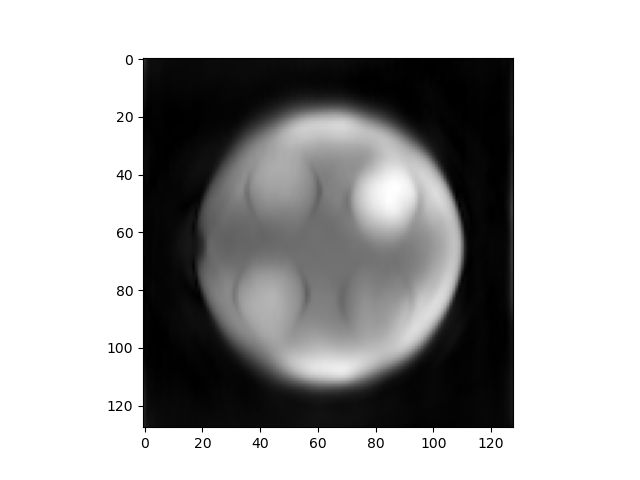

In [20]:
plt.figure()
plt.imshow(torch.abs(img_cs[0, :, :, 128//2]).cpu().numpy(), cmap='gray')

In [21]:
h5_output.close()